# 🌐 English → French Machine Translation — EDA & Transformer Model
**Goal:** Build a **Transformer** (encoder-decoder with multi-head attention) from scratch in PyTorch to translate English sentences to French.

---
## Table of Contents
1. [Setup & Data](#1)
2. [Exploratory Data Analysis](#2)
3. [Tokenisation & Vocabulary](#3)
4. [Dataset & DataLoader](#4)
5. [Transformer Architecture](#5)
6. [Training](#6)
7. [Evaluation & BLEU Score](#7)
8. [Save Artefacts](#8)


## 1. Setup & Data <a id='1'></a>

In [1]:
import warnings, os, math, re, joblib, random, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style="darkgrid")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4)})

os.makedirs("../models", exist_ok=True)
os.makedirs("../data",   exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}  |  Device : {DEVICE}")


PyTorch : 2.12.0+cpu  |  Device : cpu


In [2]:
# ── English-French sentence pairs (curated subset) ───────────────────────────
EN_FR_PAIRS = [
    ("I am happy.", "Je suis heureux."),
    ("She is reading a book.", "Elle lit un livre."),
    ("The cat is on the table.", "Le chat est sur la table."),
    ("We are going to the market.", "Nous allons au marché."),
    ("He loves music.", "Il aime la musique."),
    ("The weather is nice today.", "Le temps est beau aujourd'hui."),
    ("Can you help me?", "Pouvez-vous m'aider?"),
    ("I would like some water.", "Je voudrais de l'eau."),
    ("The train arrives at noon.", "Le train arrive à midi."),
    ("She speaks French very well.", "Elle parle très bien le français."),
    ("Good morning!", "Bonjour!"),
    ("Good night.", "Bonne nuit."),
    ("Thank you very much.", "Merci beaucoup."),
    ("Where is the station?", "Où est la gare?"),
    ("I do not understand.", "Je ne comprends pas."),
    ("The children are playing outside.", "Les enfants jouent dehors."),
    ("My name is John.", "Je m'appelle John."),
    ("How old are you?", "Quel âge avez-vous?"),
    ("I like coffee.", "J'aime le café."),
    ("The door is open.", "La porte est ouverte."),
    ("She is a doctor.", "Elle est médecin."),
    ("We live in Paris.", "Nous vivons à Paris."),
    ("He is sleeping.", "Il dort."),
    ("The sky is blue.", "Le ciel est bleu."),
    ("I have two brothers.", "J'ai deux frères."),
    ("The food is delicious.", "La nourriture est délicieuse."),
    ("Please sit down.", "Veuillez vous asseoir."),
    ("I am learning French.", "J'apprends le français."),
    ("The book is on the shelf.", "Le livre est sur l'étagère."),
    ("She is wearing a red dress.", "Elle porte une robe rouge."),
    ("It is raining outside.", "Il pleut dehors."),
    ("I love you.", "Je t'aime."),
    ("See you tomorrow.", "À demain."),
    ("The museum is closed.", "Le musée est fermé."),
    ("He works in a hospital.", "Il travaille dans un hôpital."),
    ("We are eating dinner.", "Nous dînons."),
    ("The flowers are beautiful.", "Les fleurs sont belles."),
    ("I am tired.", "Je suis fatigué."),
    ("She has a cat.", "Elle a un chat."),
    ("The road is long.", "La route est longue."),
    ("He is a good student.", "Il est un bon étudiant."),
    ("I want to go home.", "Je veux rentrer à la maison."),
    ("The coffee is hot.", "Le café est chaud."),
    ("We are best friends.", "Nous sommes les meilleurs amis."),
    ("She is cooking dinner.", "Elle prépare le dîner."),
    ("The library is quiet.", "La bibliothèque est calme."),
    ("He plays the piano.", "Il joue du piano."),
    ("I need a vacation.", "J'ai besoin de vacances."),
    ("The sun rises in the east.", "Le soleil se lève à l'est."),
    ("She is very kind.", "Elle est très gentille."),
    ("We take the bus every day.", "Nous prenons le bus chaque jour."),
    ("The movie was interesting.", "Le film était intéressant."),
    ("I forgot my keys.", "J'ai oublié mes clés."),
    ("He is walking to school.", "Il marche jusqu'à l'école."),
    ("The baby is crying.", "Le bébé pleure."),
    ("She bought a new car.", "Elle a acheté une nouvelle voiture."),
    ("The restaurant is full.", "Le restaurant est plein."),
    ("I enjoy reading novels.", "J'aime lire des romans."),
    ("He speaks very loudly.", "Il parle très fort."),
    ("We visited the Eiffel Tower.", "Nous avons visité la Tour Eiffel."),
    ("The exam was difficult.", "L'examen était difficile."),
    ("She is smiling.", "Elle sourit."),
    ("I have a headache.", "J'ai mal à la tête."),
    ("The dog is barking.", "Le chien aboie."),
    ("He ordered a pizza.", "Il a commandé une pizza."),
    ("We are on holiday.", "Nous sommes en vacances."),
    ("The garden is beautiful.", "Le jardin est beau."),
    ("She forgot her umbrella.", "Elle a oublié son parapluie."),
    ("I am going to the gym.", "Je vais à la salle de sport."),
    ("The concert starts at eight.", "Le concert commence à huit heures."),
    ("He is a famous artist.", "Il est un artiste célèbre."),
    ("We enjoy cooking together.", "Nous aimons cuisiner ensemble."),
    ("The winter is cold.", "L'hiver est froid."),
    ("She passed the exam.", "Elle a réussi l'examen."),
    ("I saw a beautiful bird.", "J'ai vu un beau oiseau."),
    ("He drinks orange juice.", "Il boit du jus d'orange."),
    ("The hotel is very comfortable.", "L'hôtel est très confortable."),
    ("We watched the sunrise.", "Nous avons regardé le lever du soleil."),
    ("She is writing a letter.", "Elle écrit une lettre."),
    ("I called my mother.", "J'ai appelé ma mère."),
    ("The children love chocolate.", "Les enfants adorent le chocolat."),
    ("He is fixing the car.", "Il répare la voiture."),
    ("We need more time.", "Nous avons besoin de plus de temps."),
    ("The park is nearby.", "Le parc est tout près."),
    ("She is a great teacher.", "Elle est un excellent professeur."),
    ("I missed the train.", "J'ai raté le train."),
    ("He won the competition.", "Il a gagné le concours."),
    ("We are watching a movie.", "Nous regardons un film."),
    ("The summer is very hot.", "L'été est très chaud."),
    ("She is learning to drive.", "Elle apprend à conduire."),
    ("I bought fresh bread.", "J'ai acheté du pain frais."),
    ("He is very intelligent.", "Il est très intelligent."),
    ("We arrived late.", "Nous sommes arrivés en retard."),
    ("The stars are shining.", "Les étoiles brillent."),
    ("She is answering the phone.", "Elle répond au téléphone."),
    ("I want to learn Spanish.", "Je veux apprendre l'espagnol."),
    ("He is riding a bicycle.", "Il fait du vélo."),
    ("We are planning a trip.", "Nous planifions un voyage."),
    ("The soup is warm.", "La soupe est chaude."),
    ("She loves dancing.", "Elle aime danser."),
    ("I need to buy groceries.", "Je dois acheter des courses."),
    ("He is reading the newspaper.", "Il lit le journal."),
    ("We are very excited.", "Nous sommes très excités."),
    ("The baby is sleeping.", "Le bébé dort."),
    ("She painted the wall blue.", "Elle a peint le mur en bleu."),
    ("I visited my grandparents.", "J'ai rendu visite à mes grands-parents."),
    ("He is tall and handsome.", "Il est grand et beau."),
    ("We go swimming every Sunday.", "Nous nageons chaque dimanche."),
    ("The autumn leaves are falling.", "Les feuilles d'automne tombent."),
    ("She is very creative.", "Elle est très créative."),
    ("I lost my wallet.", "J'ai perdu mon portefeuille."),
    ("He is late for work.", "Il est en retard pour le travail."),
    ("We enjoyed the concert.", "Nous avons apprécié le concert."),
    ("The city is very busy.", "La ville est très animée."),
    ("She is preparing for exams.", "Elle se prépare pour les examens."),
    ("I found a new job.", "J'ai trouvé un nouvel emploi."),
    ("He is a wonderful father.", "Il est un père merveilleux."),
    ("We celebrated our anniversary.", "Nous avons célébré notre anniversaire."),
    ("The lake is very deep.", "Le lac est très profond."),
    ("She enjoys painting landscapes.", "Elle aime peindre des paysages."),
    ("I drink tea every morning.", "Je bois du thé chaque matin."),
    ("He runs very fast.", "Il court très vite."),
    ("We are proud of you.", "Nous sommes fiers de toi."),
    ("The bridge is very old.", "Le pont est très vieux."),
    ("She is my best friend.", "Elle est ma meilleure amie."),
    ("I am reading a novel.", "Je lis un roman."),
]

df = pd.DataFrame(EN_FR_PAIRS, columns=["english", "french"])
df.to_csv("../data/en_fr_pairs.csv", index=False)
print(f"Dataset: {len(df)} sentence pairs")
df.head(8)


Dataset: 126 sentence pairs


,english,french
0,I am happy.,Je suis heureux.
1,She is reading a book.,Elle lit un livre.
2,The cat is on the table.,Le chat est sur la table.
3,We are going to the market.,Nous allons au marché.
4,He loves music.,Il aime la musique.
5,The weather is nice today.,Le temps est beau aujourd'hui.
6,Can you help me?,Pouvez-vous m'aider?
7,I would like some water.,Je voudrais de l'eau.


## 2. Exploratory Data Analysis <a id='2'></a>

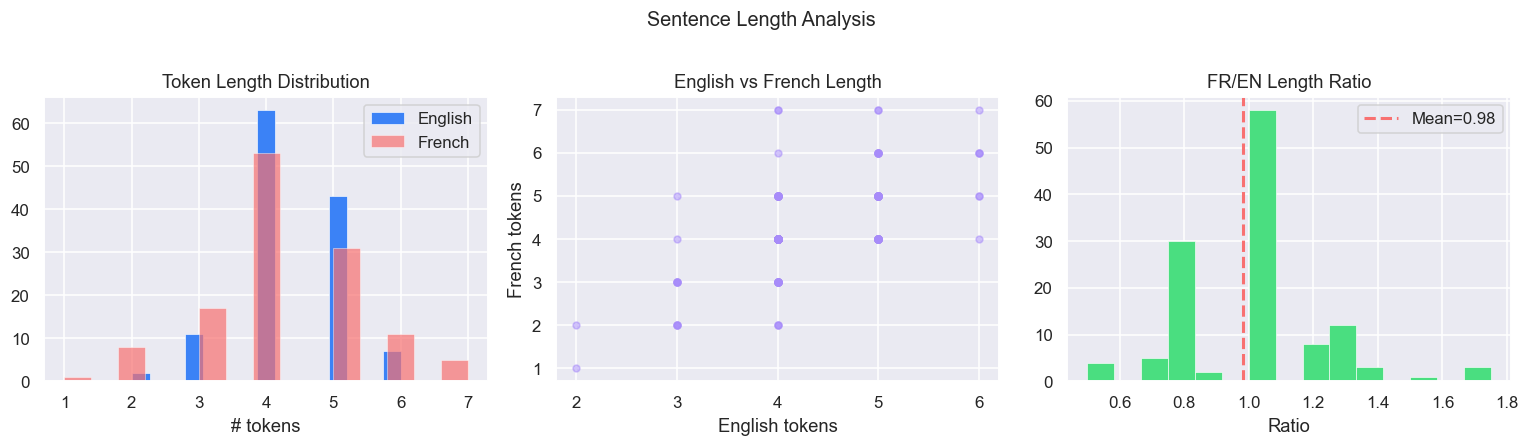

English — mean: 4.3  max: 6
French  — mean: 4.3  max: 7


In [3]:
# Sentence length distributions
df["en_len"] = df["english"].apply(lambda x: len(x.split()))
df["fr_len"] = df["french"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["en_len"], bins=15, color="#3b82f6", edgecolor="white", linewidth=0.4, label="English")
axes[0].hist(df["fr_len"], bins=15, color="#f87171", edgecolor="white", linewidth=0.4, alpha=0.7, label="French")
axes[0].set_title("Token Length Distribution"); axes[0].set_xlabel("# tokens"); axes[0].legend()

axes[1].scatter(df["en_len"], df["fr_len"], alpha=0.5, color="#a78bfa", s=20)
axes[1].set_title("English vs French Length"); axes[1].set_xlabel("English tokens"); axes[1].set_ylabel("French tokens")

length_ratio = df["fr_len"] / df["en_len"]
axes[2].hist(length_ratio, bins=15, color="#4ade80", edgecolor="white", linewidth=0.4)
axes[2].axvline(length_ratio.mean(), color="#f87171", linewidth=2, linestyle="--",
                label=f"Mean={length_ratio.mean():.2f}")
axes[2].set_title("FR/EN Length Ratio"); axes[2].set_xlabel("Ratio"); axes[2].legend()

plt.suptitle("Sentence Length Analysis", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"English — mean: {df['en_len'].mean():.1f}  max: {df['en_len'].max()}")
print(f"French  — mean: {df['fr_len'].mean():.1f}  max: {df['fr_len'].max()}")


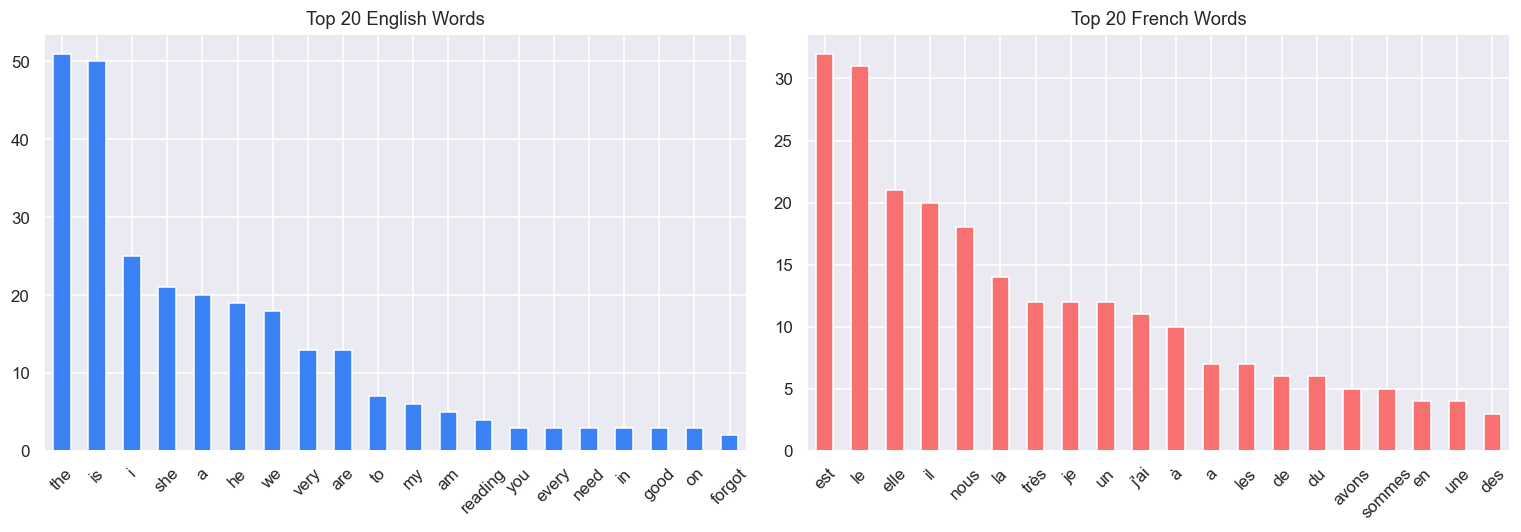

In [4]:
# Most common English words
en_words = " ".join(df["english"].str.lower()).split()
fr_words = " ".join(df["french"].str.lower()).split()

en_freq = pd.Series(Counter(en_words)).sort_values(ascending=False).head(20)
fr_freq = pd.Series(Counter(fr_words)).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
en_freq.plot(kind="bar", ax=axes[0], color="#3b82f6", edgecolor="white")
axes[0].set_title("Top 20 English Words"); axes[0].tick_params(axis="x", rotation=45)
fr_freq.plot(kind="bar", ax=axes[1], color="#f87171", edgecolor="white")
axes[1].set_title("Top 20 French Words"); axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


English vocab size : 255
French  vocab size : 282
Shared tokens      : 16


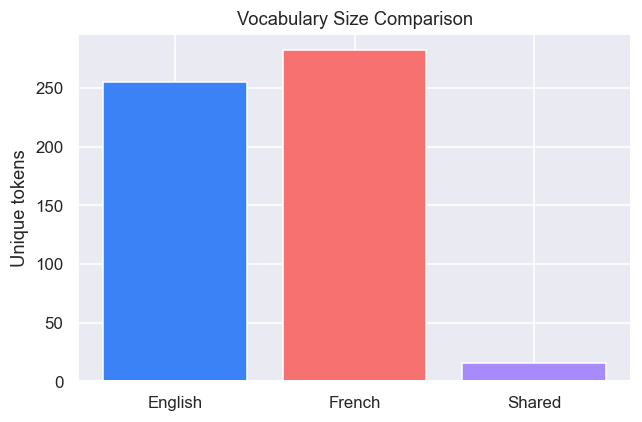

In [5]:
# Vocabulary sizes
def tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text.lower())

en_vocab = set(w for s in df["english"] for w in tokenize(s))
fr_vocab = set(w for s in df["french"]  for w in tokenize(s))

print(f"English vocab size : {len(en_vocab)}")
print(f"French  vocab size : {len(fr_vocab)}")
print(f"Shared tokens      : {len(en_vocab & fr_vocab)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["English", "French", "Shared"], [len(en_vocab), len(fr_vocab), len(en_vocab & fr_vocab)],
       color=["#3b82f6","#f87171","#a78bfa"], edgecolor="white")
ax.set_title("Vocabulary Size Comparison"); ax.set_ylabel("Unique tokens")
plt.tight_layout(); plt.show()


## 3. Tokenisation & Vocabulary <a id='3'></a>

In [6]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"

class Vocabulary:
    def __init__(self, name):
        self.name     = name
        self.word2idx = {PAD:0, SOS:1, EOS:2, UNK:3}
        self.idx2word = {0:PAD, 1:SOS, 2:EOS, 3:UNK}
        self.freq     = Counter()

    def build(self, sentences, min_freq=1):
        for s in sentences:
            for w in tokenize(s):
                self.freq[w] += 1
        for w, c in self.freq.items():
            if c >= min_freq and w not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[w] = idx
                self.idx2word[idx] = w

    def encode(self, sentence):
        return [self.word2idx.get(w, self.word2idx[UNK]) for w in tokenize(sentence)]

    def decode(self, indices):
        return " ".join(self.idx2word.get(i, UNK) for i in indices
                        if i not in (self.word2idx[PAD], self.word2idx[SOS], self.word2idx[EOS]))

    def __len__(self): return len(self.word2idx)

src_vocab = Vocabulary("english")
tgt_vocab = Vocabulary("french")
src_vocab.build(df["english"])
tgt_vocab.build(df["french"])

print(f"Source vocab (EN): {len(src_vocab)}")
print(f"Target vocab (FR): {len(tgt_vocab)}")


Source vocab (EN): 259
Target vocab (FR): 286


## 4. Dataset & DataLoader <a id='4'></a>

In [7]:
MAX_LEN = 20

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=MAX_LEN):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len   = max_len

    def __len__(self): return len(self.pairs)

    def pad(self, seq, max_len):
        seq = seq[:max_len]
        return seq + [0] * (max_len - len(seq))

    def __getitem__(self, idx):
        en, fr = self.pairs[idx]
        src = self.pad([src_vocab.word2idx[SOS]] + src_vocab.encode(en) + [src_vocab.word2idx[EOS]], MAX_LEN)
        tgt = self.pad([tgt_vocab.word2idx[SOS]] + tgt_vocab.encode(fr) + [tgt_vocab.word2idx[EOS]], MAX_LEN)
        return torch.tensor(src), torch.tensor(tgt)

pairs = list(zip(df["english"], df["french"]))
random.seed(42)
random.shuffle(pairs)

n_train = int(len(pairs) * 0.85)
train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:]

train_ds = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_ds   = TranslationDataset(val_pairs,   src_vocab, tgt_vocab)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=16, shuffle=False)

print(f"Train pairs: {len(train_ds)}  |  Val pairs: {len(val_ds)}")

# Quick sanity check
src_ex, tgt_ex = train_ds[0]
print("Sample src:", src_vocab.decode(src_ex.tolist()))
print("Sample tgt:", tgt_vocab.decode(tgt_ex.tolist()))


Train pairs: 107  |  Val pairs: 19
Sample src: she speaks french very well .
Sample tgt: elle parle très bien le français .


## 5. Transformer Architecture <a id='5'></a>

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=128, nhead=4, num_encoder_layers=3,
                 num_decoder_layers=3, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.src_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=0)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=0)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.d_model = d_model
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def make_causal_mask(self, sz):
        return torch.triu(torch.ones(sz, sz), diagonal=1).bool()

    def forward(self, src, tgt):
        src_pad_mask = (src == 0)
        tgt_pad_mask = (tgt == 0)
        tgt_mask     = self.make_causal_mask(tgt.size(1)).to(src.device)

        src_emb = self.pos_enc(self.src_emb(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.tgt_emb(tgt) * math.sqrt(self.d_model))

        out = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_pad_mask,
            tgt_key_padding_mask=tgt_pad_mask,
        )
        return self.fc_out(out)


model = Seq2SeqTransformer(len(src_vocab), len(tgt_vocab)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(model)


Model params: 1,100,958
Seq2SeqTransformer(
  (src_emb): Embedding(259, 128, padding_idx=0)
  (tgt_emb): Embedding(286, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
   

## 6. Training <a id='6'></a>

In [10]:
PAD_IDX = 0
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total_loss = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt in dl:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in  = tgt[:, :-1]
            tgt_out = tgt[:, 1:]
            logits  = model(src, tgt_in)               # (B, T-1, vocab)
            loss    = criterion(logits.reshape(-1, len(tgt_vocab)), tgt_out.reshape(-1))
            if train:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(dl)

train_losses, val_losses = [], []
best_val, patience, best_state = float("inf"), 0, None
EPOCHS = 100

for epoch in range(1, EPOCHS+1):
    tr_loss = run_epoch(train_dl, train=True)
    vl_loss = run_epoch(val_dl,   train=False)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    scheduler.step(vl_loss)

    if vl_loss < best_val:
        best_val   = vl_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience   = 0
    else:
        patience  += 1
        if patience >= 15:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {tr_loss:.4f} | Val: {vl_loss:.4f}")

model.load_state_dict(best_state)
print("\nBest model restored ✅")


Epoch  10 | Train: 3.2996 | Val: 4.2962
Epoch  20 | Train: 2.3382 | Val: 4.2292
Epoch  30 | Train: 1.8050 | Val: 4.2504
Epoch  40 | Train: 1.4840 | Val: 4.2555
Early stop at epoch 44

Best model restored ✅


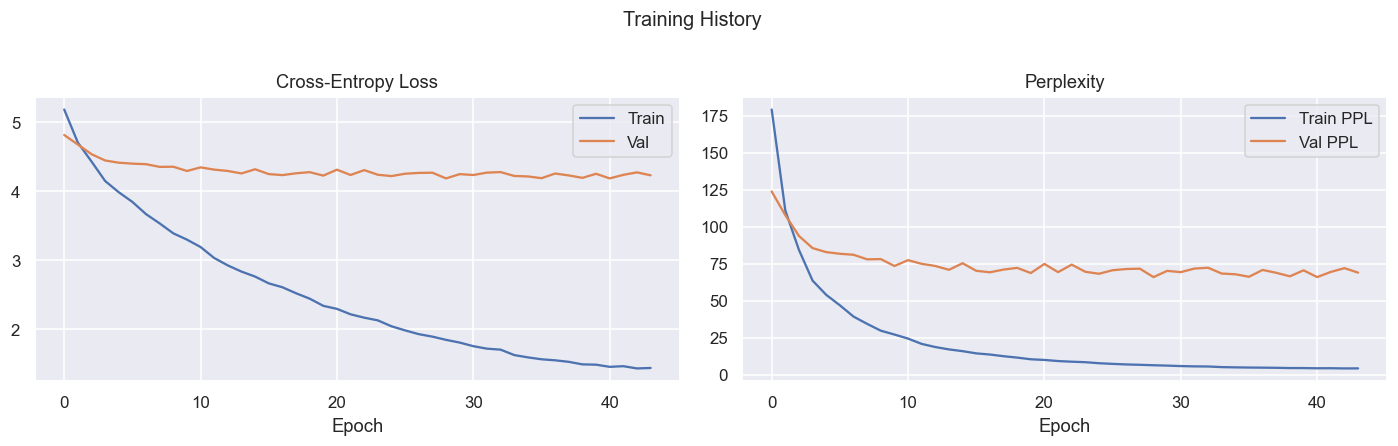

In [11]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(train_losses, label="Train"); axes[0].plot(val_losses, label="Val")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(np.exp(train_losses), label="Train PPL"); axes[1].plot(np.exp(val_losses), label="Val PPL")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.suptitle("Training History", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 7. Evaluation & BLEU Score <a id='7'></a>

In [12]:
def greedy_decode(model, sentence, src_vocab, tgt_vocab, max_len=MAX_LEN, device=DEVICE):
    model.eval()
    tokens = [src_vocab.word2idx[SOS]] + src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
    src = torch.tensor(tokens[:max_len] + [0]*(max_len - len(tokens[:max_len]))).unsqueeze(0).to(device)
    tgt = torch.tensor([tgt_vocab.word2idx[SOS]]).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_len):
            logits = model(src, tgt)
            next_token = logits[:, -1, :].argmax(-1).item()
            if next_token == tgt_vocab.word2idx[EOS]: break
            tgt = torch.cat([tgt, torch.tensor([[next_token]]).to(device)], dim=1)

    return tgt_vocab.decode(tgt.squeeze().tolist()[1:])

# Sample translations
test_sentences = [
    "I am happy.",
    "She is reading a book.",
    "The cat is on the table.",
    "Good morning!",
    "I love you.",
    "Thank you very much.",
    "The weather is nice today.",
    "We are going to the market.",
]
print(f"{'English':<35} {'Predicted French':<35} {'True French'}")
print("-" * 100)
true_map = dict(EN_FR_PAIRS)
for s in test_sentences:
    pred = greedy_decode(model, s, src_vocab, tgt_vocab)
    true = true_map.get(s, "—")
    print(f"{s:<35} {pred:<35} {true}")


English                             Predicted French                    True French
----------------------------------------------------------------------------------------------------
I am happy.                         je veux apprendre l ' ai            Je suis heureux.
She is reading a book.              elle a un livre .                   Elle lit un livre.
The cat is on the table.            le chat est très bien .             Le chat est sur la table.
Good morning!                       il est un artiste célèbre .         Bonjour!
I love you.                         je veux apprendre l ' ai            Je t'aime.
Thank you very much.                il est très un .                    Merci beaucoup.
The weather is nice today.          le temps est beau aujourd ' ai      Le temps est beau aujourd'hui.
We are going to the market.         nous sommes en vacances .           Nous allons au marché.


Mean BLEU-2 score: 0.1511


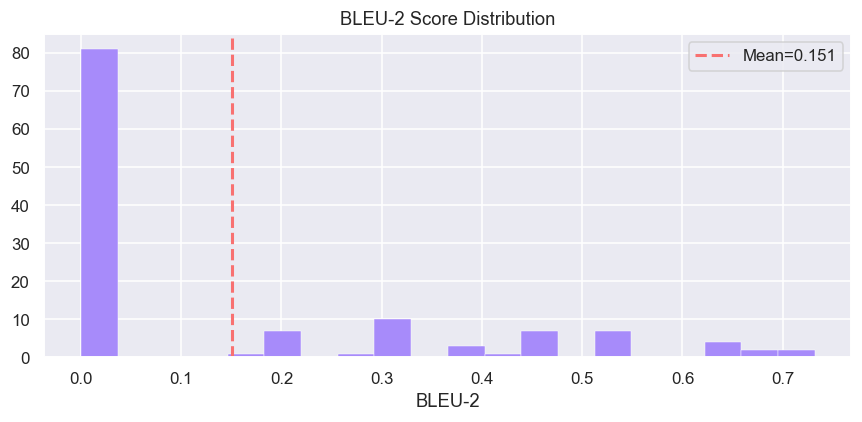

In [13]:
# BLEU score (simple unigram/bigram)
def bleu_score(candidate, reference):
    """Simple BLEU-2 implementation."""
    cand_tokens = candidate.lower().split()
    ref_tokens  = reference.lower().split()
    if len(cand_tokens) == 0: return 0.0
    # Brevity penalty
    bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1)))
    # Unigram precision
    ref_counter = Counter(ref_tokens)
    cand_counter = Counter(cand_tokens)
    p1 = sum(min(c, ref_counter[w]) for w, c in cand_counter.items()) / max(len(cand_tokens), 1)
    # Bigram precision
    ref_bigrams  = Counter(zip(ref_tokens[:-1],  ref_tokens[1:]))
    cand_bigrams = Counter(zip(cand_tokens[:-1], cand_tokens[1:]))
    p2_num = sum(min(c, ref_bigrams[bg]) for bg, c in cand_bigrams.items())
    p2_den = max(len(cand_tokens) - 1, 1)
    p2 = p2_num / p2_den
    return bp * math.exp(0.5 * math.log(max(p1, 1e-9)) + 0.5 * math.log(max(p2, 1e-9)))

bleu_scores = []
for en, fr_true in pairs:
    pred = greedy_decode(model, en, src_vocab, tgt_vocab)
    bleu_scores.append(bleu_score(pred, fr_true))

mean_bleu = np.mean(bleu_scores)
print(f"Mean BLEU-2 score: {mean_bleu:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(bleu_scores, bins=20, color="#a78bfa", edgecolor="white", linewidth=0.3)
ax.axvline(mean_bleu, color="#f87171", linewidth=2, linestyle="--", label=f"Mean={mean_bleu:.3f}")
ax.set_title("BLEU-2 Score Distribution"); ax.set_xlabel("BLEU-2"); ax.legend()
plt.tight_layout(); plt.show()


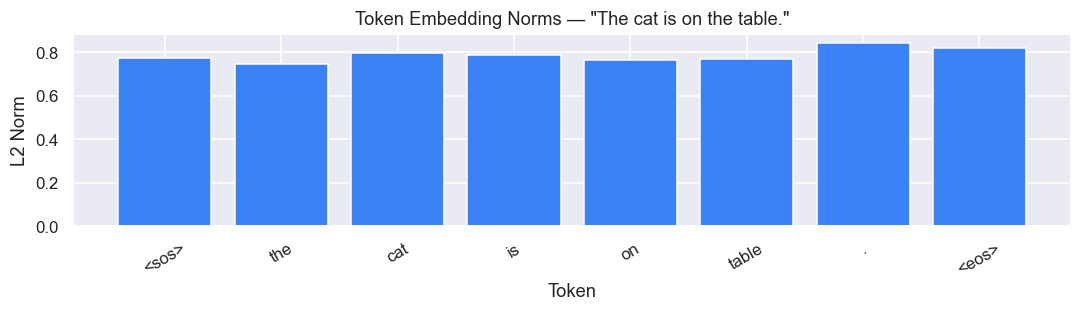

In [14]:
# Attention visualisation (encoder self-attention of first head)
def get_attention_weights(model, sentence, src_vocab, device=DEVICE):
    model.eval()
    tokens = [src_vocab.word2idx[SOS]] + src_vocab.encode(sentence) + [src_vocab.word2idx[EOS]]
    src = torch.tensor(tokens + [0]*(MAX_LEN - len(tokens))).unsqueeze(0).to(device)
    # Hook into first encoder layer's self-attention
    attn_weights = []
    def hook(module, input, output):
        # output[1] is attn weights if need_weights=True
        pass  # nn.Transformer doesn't expose attn by default; visualise embedding norms instead
    # Visualise token embedding norms as proxy for importance
    with torch.no_grad():
        emb = model.src_emb(src).squeeze(0)   # (T, d_model)
        norms = emb.norm(dim=-1).cpu().numpy()[:len(tokens)]
    return tokens, norms

sentence_vis = "The cat is on the table."
tokens_vis, norms_vis = get_attention_weights(model, sentence_vis, src_vocab)
token_words = [src_vocab.idx2word.get(t, UNK) for t in tokens_vis]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(token_words, norms_vis, color="#3b82f6", edgecolor="white")
ax.set_title(f'Token Embedding Norms — "{sentence_vis}"')
ax.set_xlabel("Token"); ax.set_ylabel("L2 Norm")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


In [15]:
# Side-by-side comparison table
results = []
for en, fr_true in random.sample(pairs, min(20, len(pairs))):
    pred  = greedy_decode(model, en, src_vocab, tgt_vocab)
    score = bleu_score(pred, fr_true)
    results.append({"English": en, "True French": fr_true, "Predicted": pred, "BLEU-2": round(score, 3)})

res_df = pd.DataFrame(results).sort_values("BLEU-2", ascending=False)
print(res_df.to_string(index=False))


                   English                         True French                            Predicted  BLEU-2
        We need more time. Nous avons besoin de plus de temps. nous avons besoin de plus de temps .   0.732
     She bought a new car. Elle a acheté une nouvelle voiture. elle a acheté une nouvelle voiture .   0.690
     He is a good student.             Il est un bon étudiant.             il est un bon étudiant .   0.632
      We are very excited.           Nous sommes très excités.           nous sommes très excités .   0.548
          We arrived late.      Nous sommes arrivés en retard.            nous sommes en vacances .   0.387
   I saw a beautiful bird.             J'ai vu un beau oiseau.           j ' ai vu un beau oiseau .   0.327
      We are best friends.     Nous sommes les meilleurs amis.            nous sommes en vacances .   0.316
    The city is very busy.           La ville est très animée.                 il est très animée .   0.316
         We live in Paris.  

## 8. Save Artefacts <a id='8'></a>

In [16]:
torch.save(model.state_dict(), "../models/transformer_model.pth")
joblib.dump(src_vocab, "../models/src_vocab.pkl")
joblib.dump(tgt_vocab, "../models/tgt_vocab.pkl")

meta = {
    "mean_bleu":       round(float(mean_bleu), 4),
    "train_loss":      round(float(train_losses[-1]), 4),
    "val_loss":        round(float(val_losses[-1]),   4),
    "params":          int(sum(p.numel() for p in model.parameters())),
    "src_vocab_size":  len(src_vocab),
    "tgt_vocab_size":  len(tgt_vocab),
    "max_len":         MAX_LEN,
}
joblib.dump(meta, "../models/model_meta.pkl")

print("Saved:")
print("  models/transformer_model.pth")
print("  models/src_vocab.pkl")
print("  models/tgt_vocab.pkl")
print("  models/model_meta.pkl")
print("\n🎉 Done! Run: streamlit run app.py")


Saved:
  models/transformer_model.pth
  models/src_vocab.pkl
  models/tgt_vocab.pkl
  models/model_meta.pkl

🎉 Done! Run: streamlit run app.py
